In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features = pd.read_csv('data/features.csv')
print(features.shape)
print(features['category'].value_counts())

(33684, 44)
category
FILE_TRANSFER    29993
STREAMING         1764
CHAT              1281
VOIP               610
C2                  36
Name: count, dtype: int64


In [2]:
# Step 2.1 -- Stratified train / val / test split (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X = features.drop(columns=['is_vpn', 'app', 'category'])
y_cat = features['category']
y_vpn = features['is_vpn'].astype(int)

# First cut: 70% train, 30% temp -- stratify on category (most imbalanced)
X_train, X_temp, y_cat_train, y_cat_temp, y_vpn_train, y_vpn_temp = train_test_split(
    X, y_cat, y_vpn,
    test_size=0.30, random_state=42, stratify=y_cat
)

# Second cut: split temp 50/50 -> 15% val, 15% test
X_val, X_test, y_cat_val, y_cat_test, y_vpn_val, y_vpn_test = train_test_split(
    X_temp, y_cat_temp, y_vpn_temp,
    test_size=0.50, random_state=42, stratify=y_cat_temp
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print()
print("Category distribution (proportions):")
for split, y in [('Train', y_cat_train), ('Val', y_cat_val), ('Test', y_cat_test)]:
    print(f"  {split}: {y.value_counts(normalize=True).round(3).to_dict()}")

Train: 23,578  Val: 5,053  Test: 5,053

Category distribution (proportions):
  Train: {'FILE_TRANSFER': 0.89, 'STREAMING': 0.052, 'CHAT': 0.038, 'VOIP': 0.018, 'C2': 0.001}
  Val: {'FILE_TRANSFER': 0.891, 'STREAMING': 0.052, 'CHAT': 0.038, 'VOIP': 0.018, 'C2': 0.001}
  Test: {'FILE_TRANSFER': 0.89, 'STREAMING': 0.052, 'CHAT': 0.038, 'VOIP': 0.018, 'C2': 0.001}


Training set class counts and imbalance ratio vs majority:
  FILE_TRANSFER   20994  (1.000x)
  STREAMING        1235  (0.059x)
  CHAT              897  (0.043x)
  VOIP              427  (0.020x)
  C2                 25  (0.001x)


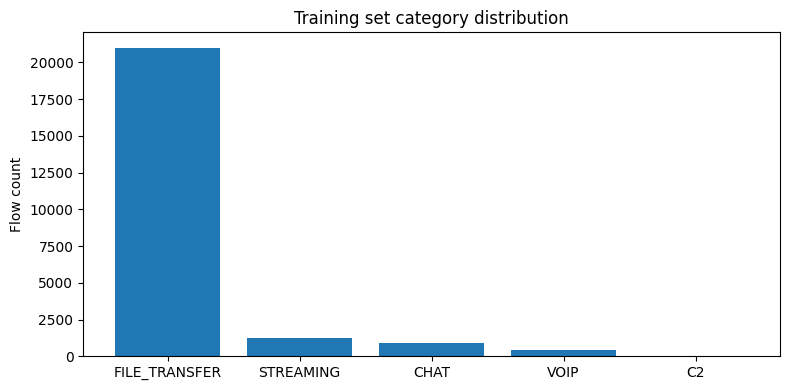

In [3]:
# Step 2.2 -- Class imbalance analysis
import matplotlib.pyplot as plt
import numpy as np

counts = y_cat_train.value_counts()
ratios = counts / counts.max()

print("Training set class counts and imbalance ratio vs majority:")
for cls, n in counts.items():
    print(f"  {cls:<15} {n:>5}  ({ratios[cls]:.3f}x)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index, counts.values)
ax.set_ylabel('Flow count')
ax.set_title('Training set category distribution')
plt.tight_layout()
plt.show()

In [15]:
# Class weights (inverse-frequency) -- no data augmentation, works with all models
from sklearn.utils.class_weight import compute_class_weight

import numpy as np
max_weight = 20.0
class_weight_dict = {cls: min(w, max_weight) for cls, w in class_weight_dict.items()}


classes = np.unique(y_cat_train)
weights = compute_class_weight('balanced', classes=classes, y=y_cat_train)
class_weight_dict = {
    'FILE_TRANSFER': 0.25,
    'STREAMING':     2.0,
    'CHAT':          3.0,
    'VOIP':          3.0,
    'C2':           15.0,   # high but not 188
}

print("Class weights (balanced):")
for cls, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    print(f"  {cls:<15} {w:.3f}")

Class weights (balanced):
  C2              15.000
  CHAT            3.000
  VOIP            3.000
  STREAMING       2.000
  FILE_TRANSFER   0.250


In [16]:
# Shared evaluation helper
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt

def evaluate(name, model, X_val, y_val):
    preds = model.predict(X_val)
    macro_f1 = f1_score(y_val, preds, average='macro')
    print(f"=== {name}  (macro F1: {macro_f1:.4f}) ===")
    print(classification_report(y_val, preds))

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_val, preds, ax=ax, colorbar=False,
                                            xticks_rotation=30)
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return macro_f1

c:\Users\apier\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression  (macro F1: 0.7896) ===
               precision    recall  f1-score   support

           C2       0.40      0.80      0.53         5
         CHAT       0.90      0.87      0.88       192
FILE_TRANSFER       0.98      0.99      0.99      4500
    STREAMING       0.87      0.87      0.87       264
         VOIP       0.76      0.61      0.67        92

     accuracy                           0.97      5053
    macro avg       0.78      0.83      0.79      5053
 weighted avg       0.97      0.97      0.97      5053



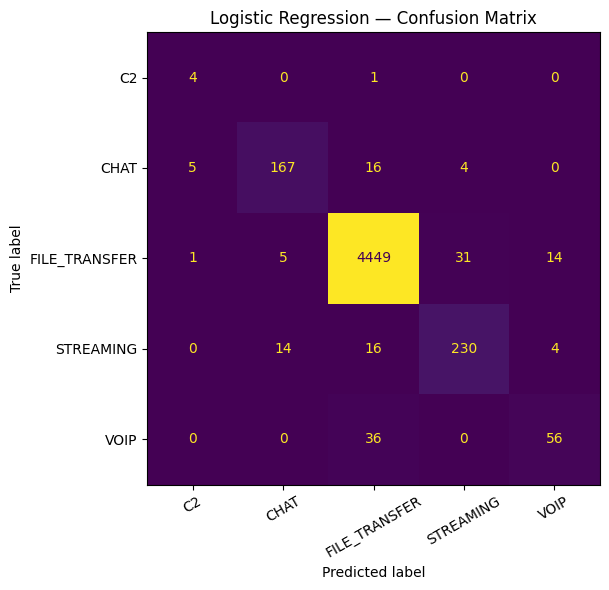

In [17]:
# Logistic Regression -- baseline reference
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1
    ))
])
lr.fit(X_train, y_cat_train)
lr_f1 = evaluate('Logistic Regression', lr, X_val, y_cat_val)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
=== Random Forest  (macro F1: 0.8647) ===
               precision    recall  f1-score   support

           C2       0.21      0.80      0.33         5
         CHAT       0.99      1.00      1.00       192
FILE_TRANSFER       1.00      1.00      1.00      4500
    STREAMING       1.00      1.00      1.00       264
         VOIP       1.00      0.99      0.99        92

     accuracy                           1.00      5053
    macro avg       0.84      0.96      0.86      5053
 weighted avg       1.00      1.00      1.00      5053



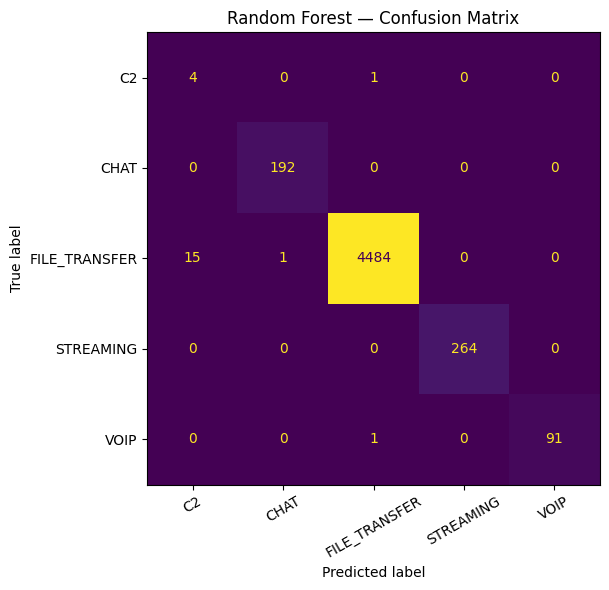

In [7]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth':    [None, 20],
    'min_samples_leaf': [1, 5],
}

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_cat_train)

print(f"Best RF params: {rf_search.best_params_}")
rf_f1 = evaluate('Random Forest', rf_search.best_estimator_, X_val, y_cat_val)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best LGBM params: {'learning_rate': 0.1, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 31}
=== LightGBM  (macro F1: 0.8611) ===
               precision    recall  f1-score   support

           C2       0.20      0.80      0.32         5
         CHAT       0.99      1.00      0.99       192
FILE_TRANSFER       1.00      1.00      1.00      4500
    STREAMING       1.00      1.00      1.00       264
         VOIP       1.00      0.99      0.99        92

     accuracy                           1.00      5053
    macro avg       0.84      0.96      0.86      5053
 weighted avg       1.00      1.00      1.00      5053



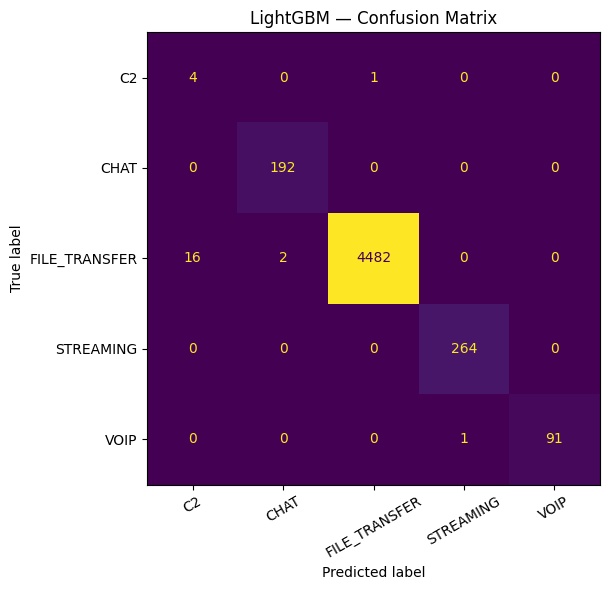

In [18]:
# LightGBM
from lightgbm import LGBMClassifier

# Convert string class weights to per-sample weights (LightGBM sample_weight)
import numpy as np
sample_weights = y_cat_train.map(class_weight_dict).values

lgbm_param_grid = {
    'learning_rate':  [0.05, 0.1],
    'num_leaves':     [31, 63],
    'n_estimators':   [200, 400],
    'min_child_samples': [10, 30],
}

lgbm_search = GridSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
lgbm_search.fit(X_train, y_cat_train, sample_weight=sample_weights)

print(f"Best LGBM params: {lgbm_search.best_params_}")
lgbm_f1 = evaluate('LightGBM', lgbm_search.best_estimator_, X_val, y_cat_val)

In [19]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Val macro-F1': [lr_f1, rf_f1, lgbm_f1],
}).sort_values('Val macro-F1', ascending=False)

print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f"Best model: {best_model_name}")

              Model  Val macro-F1
      Random Forest      0.864654
           LightGBM      0.861070
Logistic Regression      0.789578
Best model: Random Forest


In [20]:
# VPN class imbalance -- much more severe than category imbalance
vpn_counts = y_vpn_train.value_counts()
print("Training set VPN distribution:")
print(f"  Non-VPN (0): {vpn_counts[0]:,}  ({vpn_counts[0]/len(y_vpn_train):.1%})")
print(f"  VPN     (1): {vpn_counts[1]:,}  ({vpn_counts[1]/len(y_vpn_train):.1%})")
print(f"  Imbalance ratio: {vpn_counts[0]/vpn_counts[1]:.0f}:1")

Training set VPN distribution:
  Non-VPN (0): 23,315  (98.9%)
  VPN     (1): 263  (1.1%)
  Imbalance ratio: 89:1


In [21]:
# Shared binary evaluation helper (adds ROC-AUC and precision-recall curve)
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              f1_score, roc_auc_score,
                              PrecisionRecallDisplay)
import matplotlib.pyplot as plt

def evaluate_binary(name, model, X_val, y_val):
    preds  = model.predict(X_val)
    probas = model.predict_proba(X_val)[:, 1]

    macro_f1 = f1_score(y_val, preds, average='macro')
    auc      = roc_auc_score(y_val, probas)

    print(f"=== {name}  (macro F1: {macro_f1:.4f}  ROC-AUC: {auc:.4f}) ===")
    print(classification_report(y_val, preds, target_names=['Non-VPN', 'VPN']))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_val, preds, ax=ax1, colorbar=False,
        display_labels=['Non-VPN', 'VPN'])
    ax1.set_title(f'{name} — Confusion Matrix')

    PrecisionRecallDisplay.from_predictions(y_val, probas, ax=ax2,
                                             name=name)
    ax2.set_title(f'{name} — Precision-Recall Curve')
    plt.tight_layout()
    plt.show()
    return macro_f1, auc

c:\Users\apier\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression  (macro F1: 0.9651  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      4999
         VPN       0.87      1.00      0.93        54

    accuracy                           1.00      5053
   macro avg       0.94      1.00      0.97      5053
weighted avg       1.00      1.00      1.00      5053



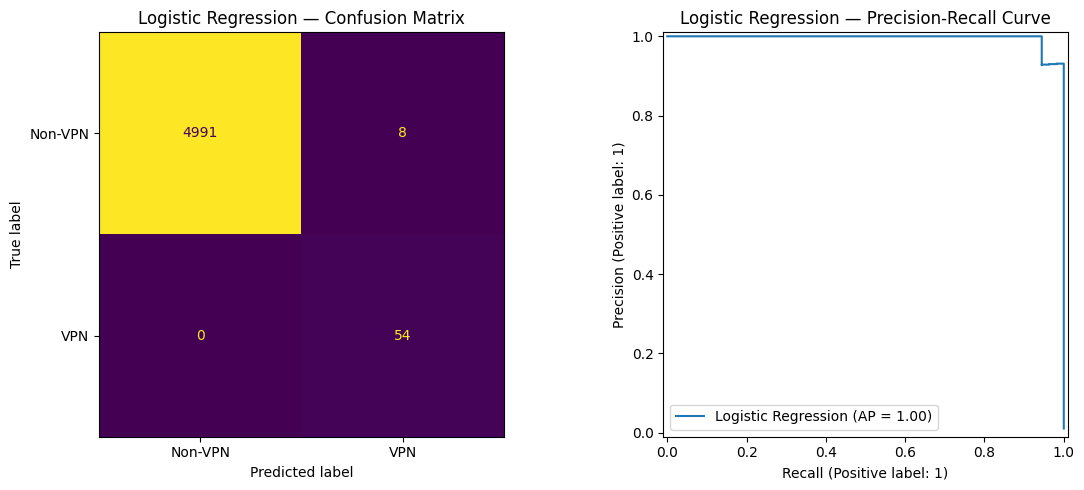

In [22]:
# Logistic Regression (binary)
lr_vpn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
lr_vpn.fit(X_train, y_vpn_train)
lr_vpn_f1, lr_vpn_auc = evaluate_binary('Logistic Regression', lr_vpn, X_val, y_vpn_val)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
=== Random Forest  (macro F1: 0.9953  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      4999
         VPN       1.00      0.98      0.99        54

    accuracy                           1.00      5053
   macro avg       1.00      0.99      1.00      5053
weighted avg       1.00      1.00      1.00      5053



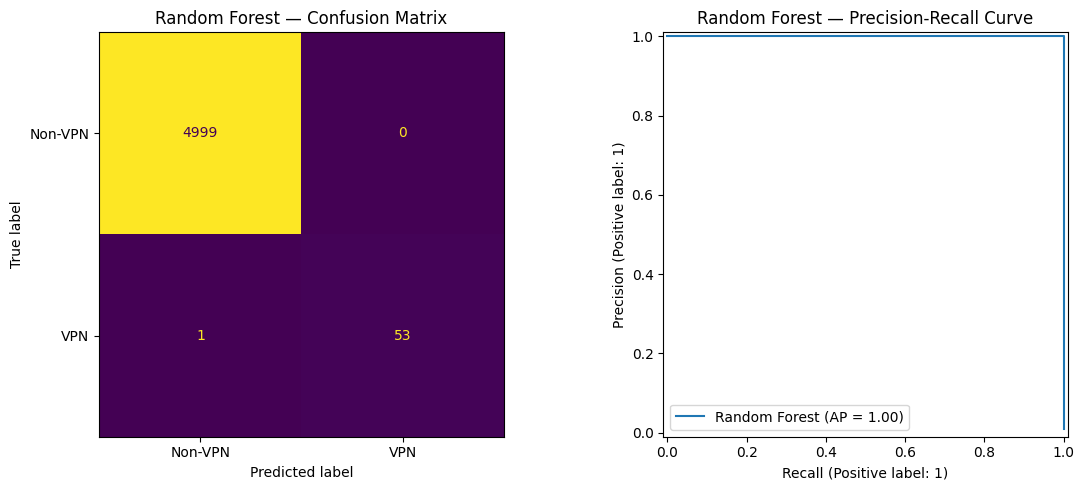

In [23]:
# Random Forest (binary)
rf_vpn_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
rf_vpn_search.fit(X_train, y_vpn_train)
print(f"Best RF params: {rf_vpn_search.best_params_}")
rf_vpn_f1, rf_vpn_auc = evaluate_binary('Random Forest', rf_vpn_search.best_estimator_, X_val, y_vpn_val)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best LGBM params: {'learning_rate': 0.05, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 31}
=== LightGBM  (macro F1: 1.0000  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      4999
         VPN       1.00      1.00      1.00        54

    accuracy                           1.00      5053
   macro avg       1.00      1.00      1.00      5053
weighted avg       1.00      1.00      1.00      5053



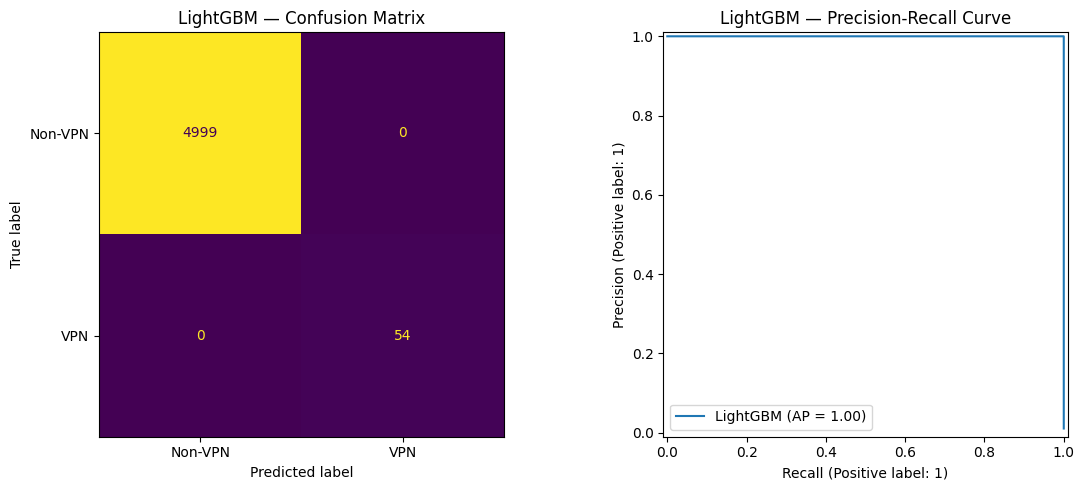

In [24]:
# LightGBM (binary)
vpn_sample_weights = y_vpn_train.map({0: 1.0, 1: y_vpn_train.value_counts()[0] / y_vpn_train.value_counts()[1]}).values

lgbm_vpn_search = GridSearchCV(
    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    lgbm_param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
lgbm_vpn_search.fit(X_train, y_vpn_train, sample_weight=vpn_sample_weights)
print(f"Best LGBM params: {lgbm_vpn_search.best_params_}")
lgbm_vpn_f1, lgbm_vpn_auc = evaluate_binary('LightGBM', lgbm_vpn_search.best_estimator_, X_val, y_vpn_val)

In [26]:
# Task B comparison
results_vpn = pd.DataFrame({
    'Model':        ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'Val macro-F1': [lr_vpn_f1, rf_vpn_f1, lgbm_vpn_f1],
    'Val ROC-AUC':  [lr_vpn_auc, rf_vpn_auc, lgbm_vpn_auc],
}).sort_values('Val macro-F1', ascending=False)

print("Task B — VPN Status Classification:")
print(results_vpn.to_string(index=False))

Task B — VPN Status Classification:
              Model  Val macro-F1  Val ROC-AUC
           LightGBM      1.000000     1.000000
      Random Forest      0.995277     1.000000
Logistic Regression      0.965117     0.999956


=== Task A: Category (test set) ===
=== LightGBM [test]  (macro F1: 0.8463) ===
               precision    recall  f1-score   support

           C2       0.16      0.50      0.24         6
         CHAT       1.00      0.99      1.00       192
FILE_TRANSFER       1.00      1.00      1.00      4499
    STREAMING       0.99      1.00      1.00       265
         VOIP       1.00      1.00      1.00        91

     accuracy                           1.00      5053
    macro avg       0.83      0.90      0.85      5053
 weighted avg       1.00      1.00      1.00      5053



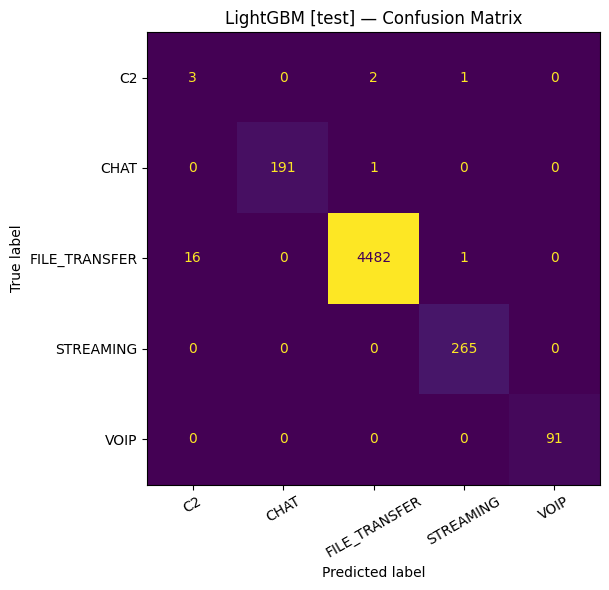

=== Task B: VPN Status (test set) ===
=== LightGBM [test]  (macro F1: 1.0000  ROC-AUC: 1.0000) ===
              precision    recall  f1-score   support

     Non-VPN       1.00      1.00      1.00      4992
         VPN       1.00      1.00      1.00        61

    accuracy                           1.00      5053
   macro avg       1.00      1.00      1.00      5053
weighted avg       1.00      1.00      1.00      5053



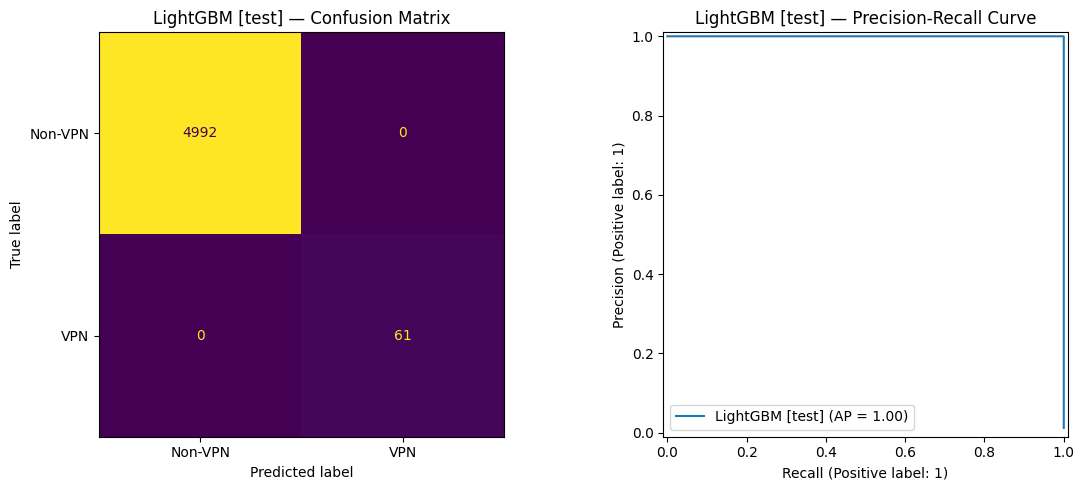

In [27]:
# Final test-set evaluation -- run ONCE after all model selection is done
# Pick the best category model and best VPN model from validation results
best_cat_model  = lgbm_search.best_estimator_   # replace if RF won
best_vpn_model  = lgbm_vpn_search.best_estimator_

print("=== Task A: Category (test set) ===")
cat_test_f1 = evaluate('LightGBM [test]', best_cat_model, X_test, y_cat_test)

print("=== Task B: VPN Status (test set) ===")
vpn_test_f1, vpn_test_auc = evaluate_binary('LightGBM [test]', best_vpn_model, X_test, y_vpn_test)

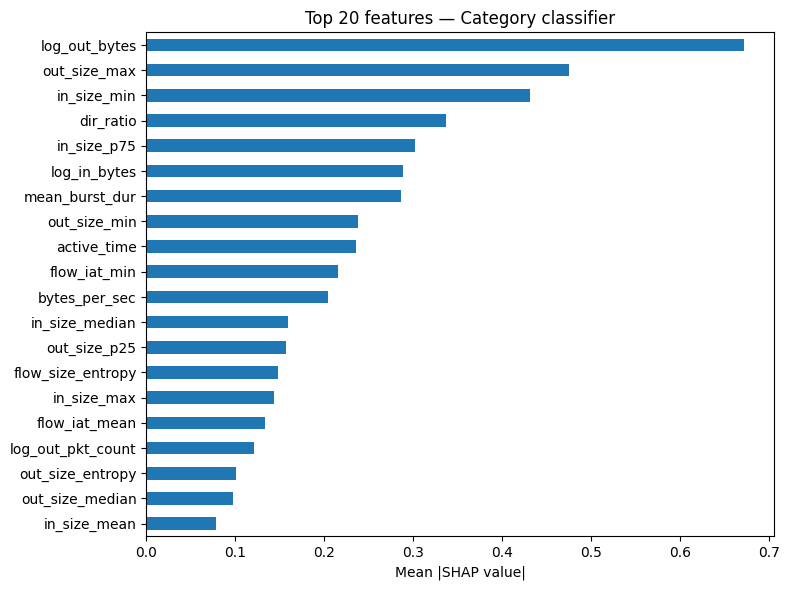

In [28]:
# SHAP feature importance -- Task A (category classification)
import shap
import numpy as np
import matplotlib.pyplot as plt

explainer_cat = shap.TreeExplainer(best_cat_model)
X_shap = X_test.sample(min(500, len(X_test)), random_state=42)
shap_vals_cat = explainer_cat.shap_values(X_shap)

# Newer SHAP returns 3D array (n_samples, n_features, n_classes).
# Older SHAP returns a list of 2D arrays [(n_samples, n_features), ...].
# Normalise to 3D so the rest of the code works regardless of version.
import numpy as np
if isinstance(shap_vals_cat, list):
    shap_vals_cat = np.stack(shap_vals_cat, axis=-1)  # -> (n_samples, n_features, n_classes)

# Mean absolute SHAP across samples and classes -> overall feature importance
feat_importance = pd.Series(
    np.abs(shap_vals_cat).mean(axis=(0, 2)),
    index=X_shap.columns
)
top20 = feat_importance.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features — Category classifier')
plt.tight_layout()
plt.show()

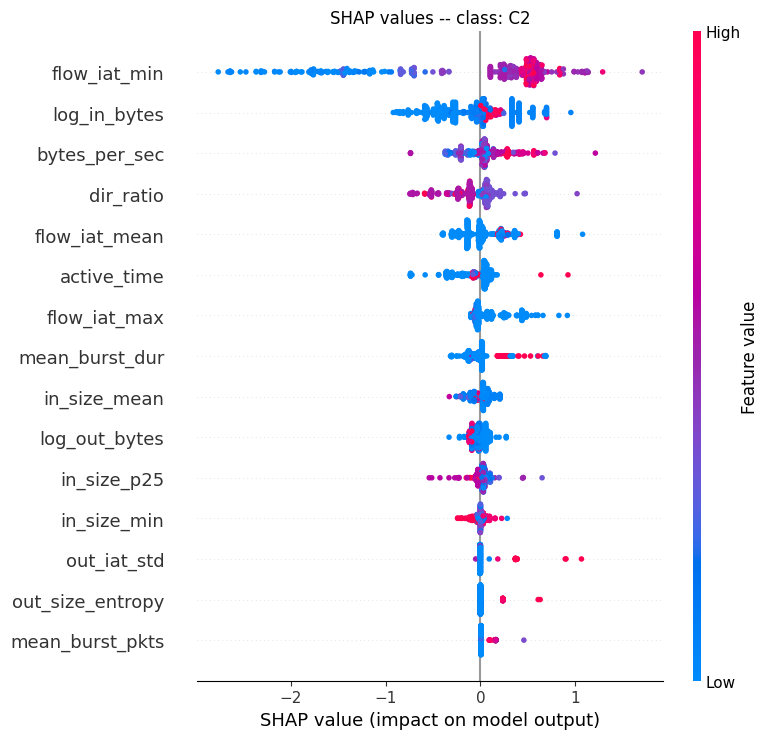

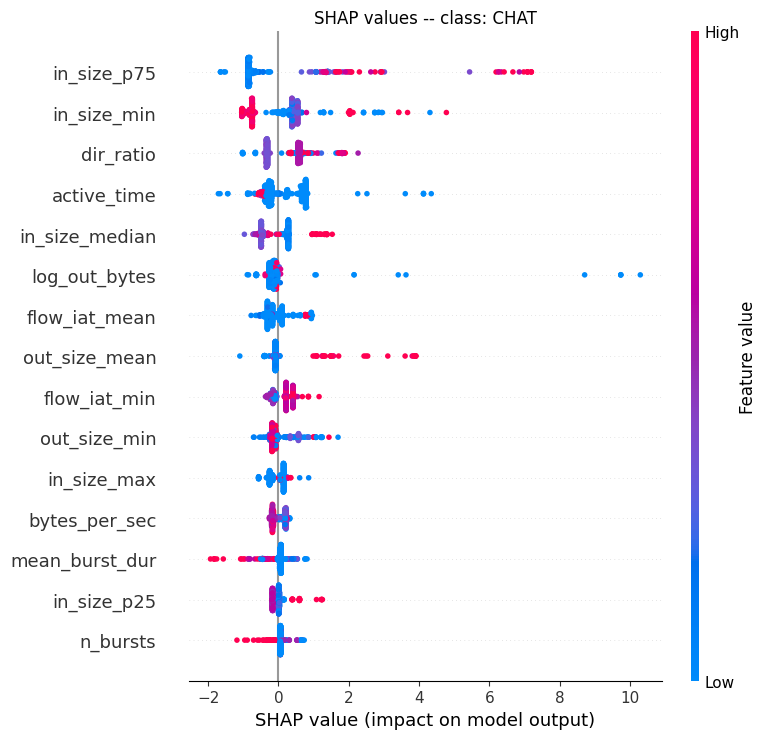

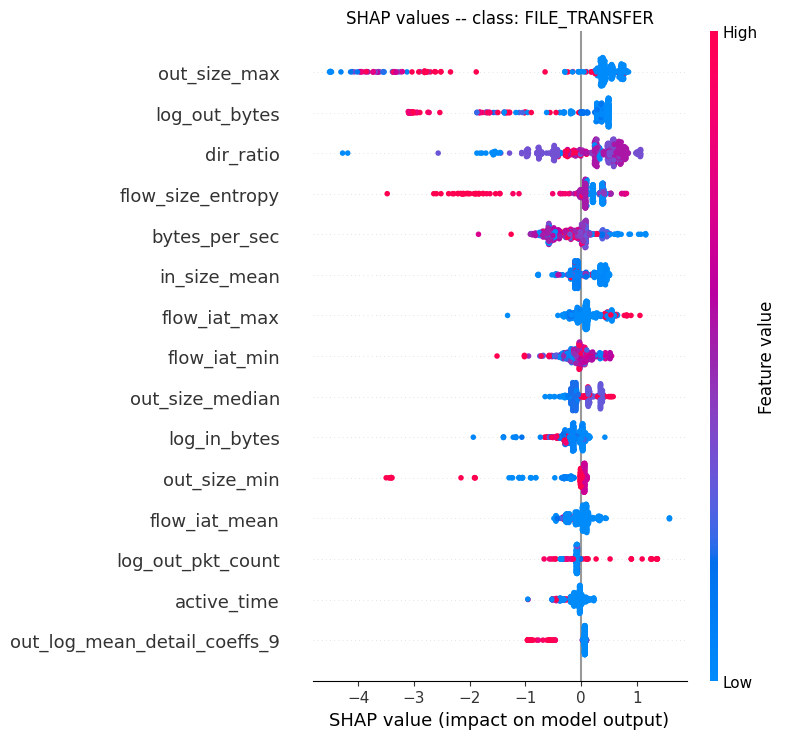

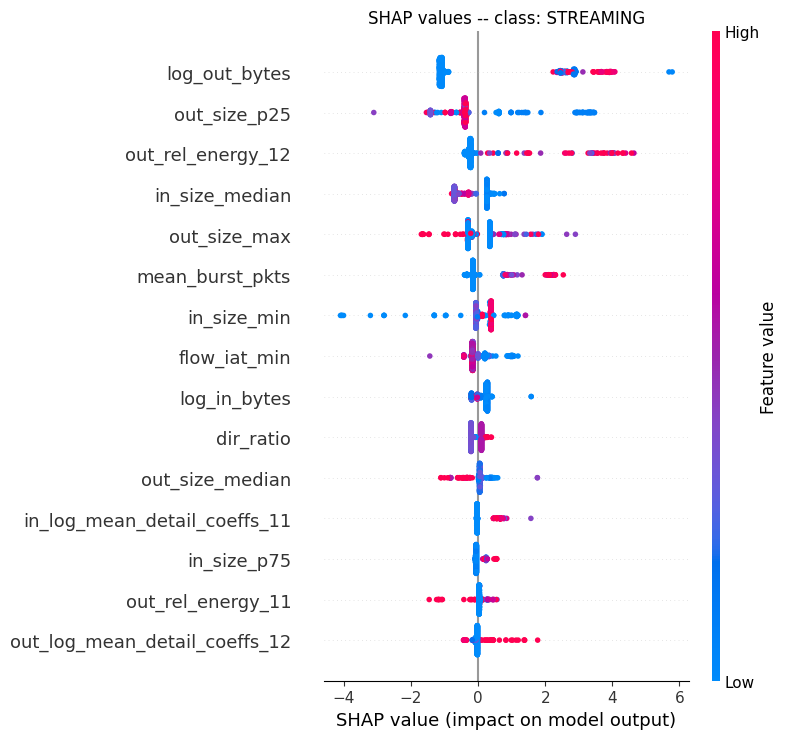

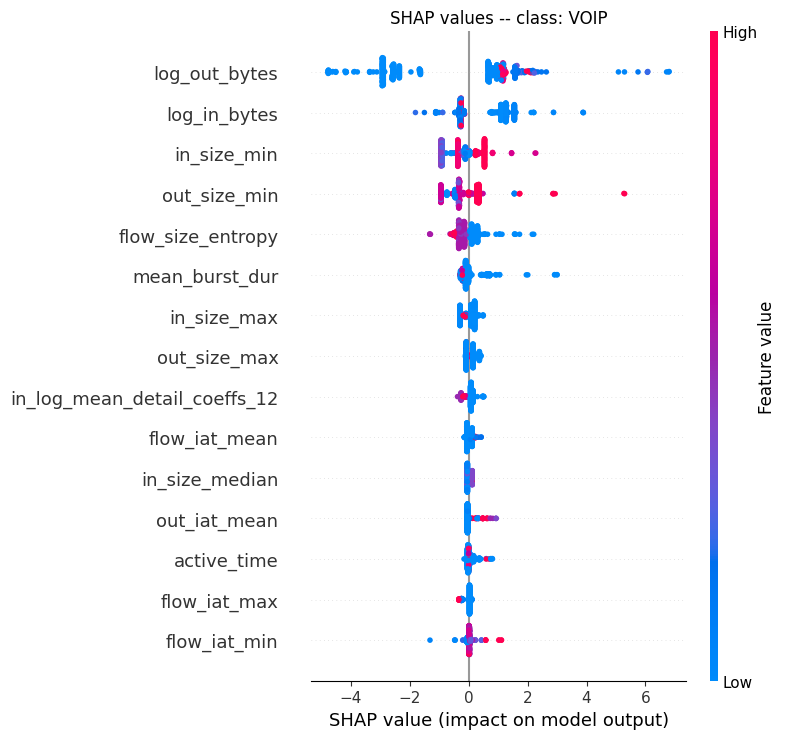

In [ ]:
# SHAP beeswarm per class
category_names = best_cat_model.classes_
for i, cls in enumerate(category_names):
    shap.summary_plot(shap_vals_cat[:, :, i], X_shap, max_display=15,
                      show=False, plot_type='dot')
    plt.title(f'SHAP values -- class: {cls}')
    plt.tight_layout()
    plt.show()

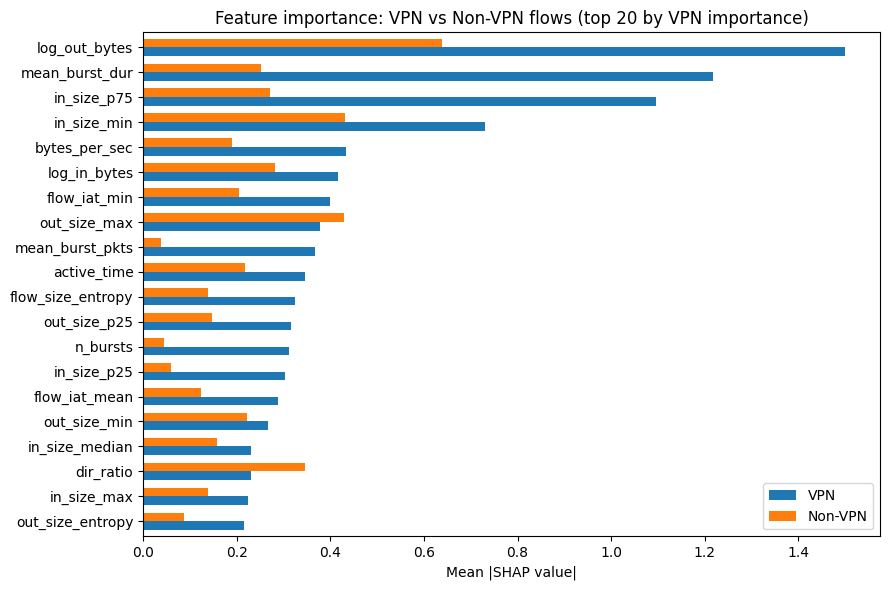

Features with largest VPN/Non-VPN importance gap:
mean_burst_pkts      9.666260
n_bursts             6.973811
in_size_p25          5.154267
mean_burst_dur       4.843551
in_size_p75          4.050742
out_size_entropy     2.476859
log_out_bytes        2.346501
flow_size_entropy    2.333569
flow_iat_mean        2.331163
bytes_per_sec        2.268531
Name: ratio, dtype: float64


In [29]:
# Feature importance: VPN subset vs Non-VPN subset
vpn_mask_test    = y_vpn_test == 1
nonvpn_mask_test = y_vpn_test == 0

X_vpn    = X_test[vpn_mask_test.values]
X_nonvpn = X_test[nonvpn_mask_test.values].sample(min(500, nonvpn_mask_test.sum()), random_state=42)

shap_vpn    = explainer_cat.shap_values(X_vpn)
shap_nonvpn = explainer_cat.shap_values(X_nonvpn)

if isinstance(shap_vpn, list):
    shap_vpn    = np.stack(shap_vpn,    axis=-1)
    shap_nonvpn = np.stack(shap_nonvpn, axis=-1)

imp_vpn    = pd.Series(np.abs(shap_vpn).mean(axis=(0, 2)),    index=X_test.columns)
imp_nonvpn = pd.Series(np.abs(shap_nonvpn).mean(axis=(0, 2)), index=X_test.columns)

comparison = pd.DataFrame({'VPN': imp_vpn, 'Non-VPN': imp_nonvpn}).nlargest(20, 'VPN')

fig, ax = plt.subplots(figsize=(9, 6))
comparison.sort_values('VPN').plot.barh(ax=ax, width=0.7)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature importance: VPN vs Non-VPN flows (top 20 by VPN importance)')
plt.tight_layout()
plt.show()

print("Features with largest VPN/Non-VPN importance gap:")
comparison['ratio'] = comparison['VPN'] / (comparison['Non-VPN'] + 1e-9)
print(comparison['ratio'].sort_values(ascending=False).head(10))

In [30]:
import joblib, os
os.makedirs('models', exist_ok=True)

joblib.dump(lr,                         'models/category_lr.joblib')
joblib.dump(rf_search.best_estimator_,  'models/category_rf.joblib')
joblib.dump(lgbm_search.best_estimator_,'models/category_lgbm.joblib')
joblib.dump(lr_vpn,                     'models/vpn_lr.joblib')
joblib.dump(rf_vpn_search.best_estimator_,   'models/vpn_rf.joblib')
joblib.dump(lgbm_vpn_search.best_estimator_, 'models/vpn_lgbm.joblib')

# Save whichever model won for each task
joblib.dump(best_cat_model, 'models/category_best.joblib')
joblib.dump(best_vpn_model, 'models/vpn_best.joblib')
print('All models saved to models/')

All models saved to models/
